# Review High Confidence Style Genre Rerun

Review notebook for `high_confidence_style_genre.csv`.


In [1]:
from pathlib import Path
import pandas as pd

def find_task_root() -> Path:
    search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    for candidate in search_roots:
        if (candidate / 'data').exists() and (candidate / 'scripts').exists() and (candidate / 'src').exists():
            return candidate
        task_root = candidate / 'Task-1'
        if (task_root / 'data').exists() and (task_root / 'scripts').exists() and (task_root / 'src').exists():
            return task_root
    raise FileNotFoundError('Could not locate the Task-1 project root.')

repo_root = find_task_root()

csv_path = repo_root / 'notebooks_rerun' / 'high_confidence_style_genre.csv'
df = pd.read_csv(csv_path).sort_values('mean_confidence', ascending=False).reset_index(drop=True)

print(f'CSV path: {csv_path}')
print(f'Rows: {len(df)}')
print(f'Columns: {len(df.columns)}')
print('Incorrect task counts:')
print(df['incorrect_tasks'].fillna('none').value_counts().to_string())


CSV path: /Users/Lenovo/Desktop/sem 6/Gsoc_HumanAi/notebooks_rerun/high_confidence_style_genre.csv
Rows: 2
Columns: 22
Incorrect task counts:
incorrect_tasks
style,genre    2


In [2]:
top_columns = ['image_path', 'incorrect_tasks', 'style_true_name', 'style_pred_name', 'style_confidence', 'genre_true_name', 'genre_pred_name', 'genre_confidence', 'artist_true_name', 'artist_pred_name', 'artist_confidence', 'mean_confidence']

top20 = df.loc[:19, top_columns].copy()
top20.index = top20.index + 1
top20


,image_path,incorrect_tasks,style_true_name,style_pred_name,style_confidence,genre_true_name,genre_pred_name,genre_confidence,artist_true_name,artist_pred_name,artist_confidence,mean_confidence
1,Analytical_Cubism/pablo-picasso_bathing-1908.jpg,"style,genre",Analytical_Cubism,Cubism,0.924207,genre_painting,nude_painting,0.996535,Pablo_Picasso,Pablo_Picasso,0.978064,0.966269
2,Naive_Art_Primitivism/martiros-saryan_armenian...,"style,genre",Naive_Art_Primitivism,Expressionism,0.897290,genre_painting,still_life,0.999851,Martiros_Saryan,Martiros_Saryan,0.986847,0.961329


In [3]:
style_genre_rows = df[['image_path', 'incorrect_tasks', 'style_true_name', 'style_pred_name', 'style_confidence', 'genre_true_name', 'genre_pred_name', 'genre_confidence', 'mean_confidence']].head(20).copy()
style_genre_rows.index = style_genre_rows.index + 1
style_genre_rows


,image_path,incorrect_tasks,style_true_name,style_pred_name,style_confidence,genre_true_name,genre_pred_name,genre_confidence,mean_confidence
1,Analytical_Cubism/pablo-picasso_bathing-1908.jpg,"style,genre",Analytical_Cubism,Cubism,0.924207,genre_painting,nude_painting,0.996535,0.966269
2,Naive_Art_Primitivism/martiros-saryan_armenian...,"style,genre",Naive_Art_Primitivism,Expressionism,0.897290,genre_painting,still_life,0.999851,0.961329


thumbnail,image_path,incorrect_tasks,style_true_name,style_pred_name,genre_true_name,genre_pred_name,artist_true_name,artist_pred_name,mean_confidence
,Analytical_Cubism/pablo-picasso_bathing-1908.jpg,"style,genre",Analytical_Cubism,Cubism,genre_painting,nude_painting,Pablo_Picasso,Pablo_Picasso,0.966269
,Naive_Art_Primitivism/martiros-saryan_armenian-woman-with-ba-lam-1915.jpg,"style,genre",Naive_Art_Primitivism,Expressionism,genre_painting,still_life,Martiros_Saryan,Martiros_Saryan,0.961329

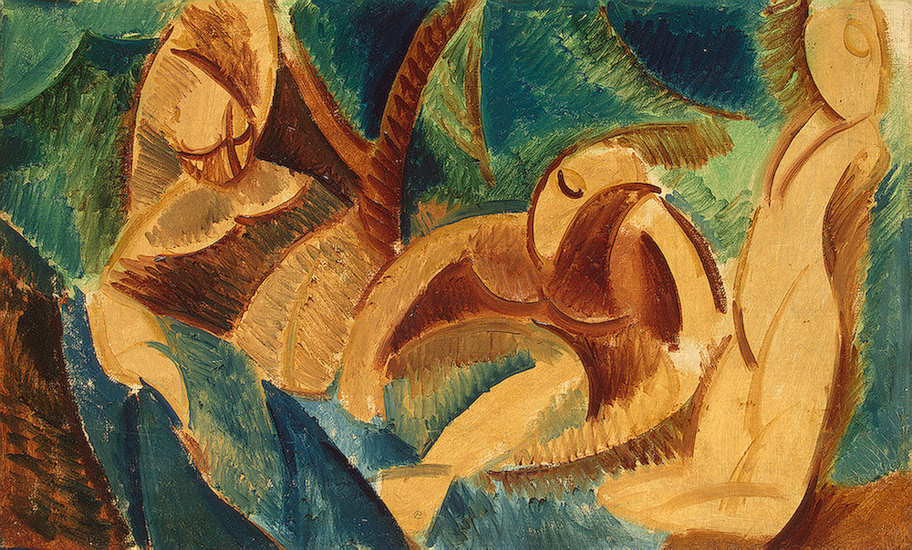
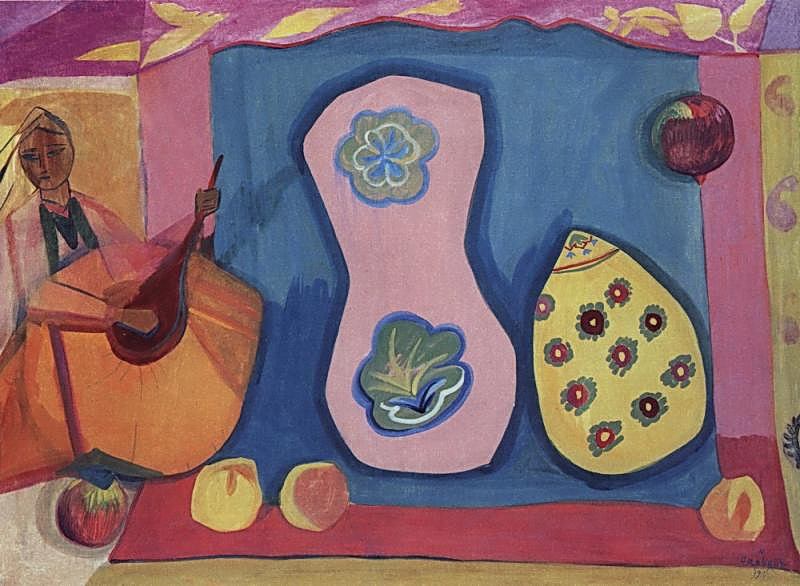

In [4]:
import base64

class HtmlDisplay(str):
    def _repr_html_(self):
        return str(self)

def image_tag(relative_path: str, width: int = 120) -> str:
    image_path = repo_root / 'data' / 'wikiart' / relative_path
    if not image_path.exists():
        return '<span style="color:#b00;">missing</span>'
    encoded = base64.b64encode(image_path.read_bytes()).decode('ascii')
    suffix = image_path.suffix.lower().lstrip('.') or 'jpeg'
    mime = 'image/jpeg' if suffix == 'jpg' else f'image/{suffix}'
    return f'<img src="data:{mime};base64,{encoded}" width="{width}" />'

review_template = df.loc[:19, ['image_path', 'incorrect_tasks', 'style_true_name', 'style_pred_name', 'genre_true_name', 'genre_pred_name', 'artist_true_name', 'artist_pred_name', 'mean_confidence']].copy()
review_template.insert(0, 'thumbnail', review_template['image_path'].map(image_tag))
HtmlDisplay(review_template.to_html(escape=False, index=False))
